# 11 -- Porownanie 4 wariantow projektu EW

Ten notebook **stosuje pełny model produkcji** z `compute_power()` do **czterech roznych konfiguracji**
i porównuje je na jednym poziomie. Każda konfiguracja wybierana jest przez **inżyniera**
(czyli Ciebie) — to dobre miejsce, żeby zobaczyć **jak decyzje projektowe wpływają na wynik**.

### Cztery warianty

| Wariant | Typ | Liczba turbin | Punkt projektowy | Intuicja |
|---------|-----|---------------|------------------|----------|
| **A** | Kaplan | 1 duża | 20% przekroczenia | Maksymalna moc na szczyt; długi przestój w sezonie suchym |
| **B** | Kaplan | 2 średnie | 30% przekroczenia | Konwencjonalny baseline (jak nb 10) |
| **C** | Kaplan | 4 małe | 30% przekroczenia | Lepsza elastyczność przy niskich Q (wiele mniejszych turbin) |
| **D** | Crossflow | 1 | 50% przekroczenia | Alternatywny typ turbiny, prosty i tańszy |

### Co porównujemy

- $P_{zainstalowana}$ [kW] — moc znamionowa
- $E_{roczna}$ [MWh/rok] — produkcja energii
- $CF$ (capacity factor) — wykorzystanie mocy
- $NPV$ — zysk całkowity w cyklu życia
- $LCOE$ — koszt jednej MWh
- $Payback$ — okres zwrotu

---

## Konfiguracja

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.imgw_data import load_processed
from src.hydrology import (
    average_sorted_year, interpolate_q_to_location, environmental_flow,
)
from src.watershed import get_station_area, find_gauge, get_catchment_area
from src.losses import trash_rack_loss, minor_loss, net_head
from src.turbine import TURBINE_CATALOG, runner_diameter, rotational_speed, synchronous_speed
from src.production import (
    compute_power, annual_energy, capacity_factor, operating_hours, average_efficiency,
)
from src.costs import total_investment, economic_analysis, EUR_PLN_RATE

pd.set_option('display.max_columns', 15)
print('Moduly zaladowane.')

Moduly zaladowane.


## Krok 1: Dane wejsciowe (Q_sorted, H_gross, Q_env)

Powtarzamy szybko proces ładowania danych z nb 10 — interpolacja Q do lokalizacji EW,
średni rok uporządkowany Q i stanu wody, model spadu netto, $Q_{env}$ jako $Q_{90\%}$.

**Prompt do LLM:**
> *"Wczytaj `daily_hydro_clean.parquet`, zinterpoluj Q do lokalizacji EW (jedna funkcja
> `interpolate_q_to_location`), wyznacz średni rok uporządkowany Q i stanu wody,
> oblicz H_gross z modelu stanu, ustaw Q_env jako Q90%."*

In [2]:
df = load_processed('../data/processed/daily_hydro_clean.parquet')
STATION_UP = '151160170'    # Brzeg Dolny
STATION_DOWN = '151160150'  # Malczyce
A_UP = get_station_area(STATION_UP)
A_DOWN = get_station_area(STATION_DOWN)
g_up = find_gauge(STATION_UP); g_down = find_gauge(STATION_DOWN)
lat_ew = (g_up['lat'] + g_down['lat']) / 2
lng_ew = (g_up['lng'] + g_down['lng']) / 2
A_TARGET = get_catchment_area(lat_ew, lng_ew, label='EW')

df_up = df[df['station_id'] == STATION_UP][['date', 'discharge_m3s', 'water_level_cm']].rename(
    columns={'discharge_m3s': 'Q_up', 'water_level_cm': 'level_up'})
df_down = df[df['station_id'] == STATION_DOWN][['date', 'discharge_m3s', 'water_level_cm']].rename(
    columns={'discharge_m3s': 'Q_down', 'water_level_cm': 'level_down'})
df_ew = df_up.merge(df_down, on='date', how='inner').dropna()
df_ew = df_ew[(df_ew['Q_up'] > 0) & (df_ew['Q_down'] > 0)].copy()
df_ew['Q_ew'] = interpolate_q_to_location(
    Q_up=df_ew['Q_up'].values, Q_down=df_ew['Q_down'].values,
    A_up=A_UP, A_down=A_DOWN, A_target=A_TARGET, method='daily_n')

df_q = pd.DataFrame({'station_id': 'EW', 'date': df_ew['date'], 'discharge_m3s': df_ew['Q_ew']})
avg_year_q = average_sorted_year(df_q, 'EW')
Q_sorted = avg_year_q['mean'].values

avg_year_lvl = average_sorted_year(df, STATION_DOWN, column='water_level_cm')
level_sorted = avg_year_lvl['mean'].values / 100.0
level_avg = (df[df['station_id'] == STATION_DOWN]['water_level_cm'].dropna() / 100.0).mean()

H_STAGE = 6.0
H_gross = np.maximum(H_STAGE + (level_avg - level_sorted), 0.0)
Q_ENV = environmental_flow(Q_sorted, method='Q90')

print(f'Q_sorted: min={Q_sorted.min():.1f}, mean={Q_sorted.mean():.1f}, max={Q_sorted.max():.1f} m3/s')
print(f'H_gross: {H_gross.min():.2f}..{H_gross.max():.2f} m')
print(f'Q_env (Q90%): {Q_ENV:.2f} m3/s')

Q_sorted: min=34.7, mean=128.1, max=441.1 m3/s
H_gross: 2.94..7.20 m
Q_env (Q90%): 58.74 m3/s


## Krok 2: Wspolna konfiguracja drogi wodnej

Wszystkie warianty używają tej samej drogi wodnej (kanał otwarty 10×2.5m, krata 30m²).
Spirale i rury ssawne skalujemy z liczbą turbin (`A = n_turbines × A_per`).

In [3]:
def manning_loss(Q, b, h, L, n_manning=0.013):
    A = b*h; P = b+2*h; R = A/P; v = Q/A
    return (n_manning * v / R**(2/3))**2 * L

A_SPIRAL_PER = 3.5
A_RUNNER_PER = 6.0

def build_loss_fns(n_turbines):
    """Zbuduj loss_fns dla danej liczby rownoleglych turbin."""
    A_sp_tot = n_turbines * A_SPIRAL_PER
    A_rr_tot = n_turbines * A_RUNNER_PER
    return [
        lambda Q: trash_rack_loss(Q, A_rack=30.0, bar_width=0.012, bar_spacing=0.05),
        lambda Q: manning_loss(Q, b=10.0, h=2.5, L=30.0, n_manning=0.013),
        lambda Q: minor_loss(Q, A=25.0, xi=0.10),
        lambda Q, A=A_sp_tot: minor_loss(Q, A=A, xi=0.10),
        lambda Q, A=A_rr_tot: minor_loss(Q, A=A, xi=0.25),
    ]

print('Helper build_loss_fns() gotowy. Spirala/rura ssawna skaluja sie z liczba turbin.')

Helper build_loss_fns() gotowy. Spirala/rura ssawna skaluja sie z liczba turbin.


## Krok 3: Definicja 4 wariantow

Każdy wariant to słownik z kompletną konfiguracją. To dobry wzorzec
(`design.yaml`-style) — wszystkie zmienne projektowe w jednym miejscu.

**Prompt do LLM:**
> *"Zdefiniuj 4 warianty jako listę słowników: typ turbiny, liczba turbin,
> punkt projektowy (% przekroczenia). Skopiuj `compute_power()` dla każdego
> wariantu i zbierz metryki do tabeli."*

In [4]:
VARIANTS = [
    dict(label='A: Kaplan 1×duza',     turbine_key='kaplan',    n_turbines=1, install_pct=20),
    dict(label='B: Kaplan 2×srednia',  turbine_key='kaplan',    n_turbines=2, install_pct=30),
    dict(label='C: Kaplan 4×mala',     turbine_key='kaplan',    n_turbines=4, install_pct=30),
    dict(label='D: Crossflow 1',       turbine_key='crossflow', n_turbines=1, install_pct=50),
]

# Parametry ekonomiczne (zgodne z nb 09 i nb 10)
ENERGY_PRICE_EUR = 106.5
OM_FRACTION = 0.025
DISCOUNT_RATE = 0.06
LIFETIME = 40

results_table = []
results_dfs = {}
for v in VARIANTS:
    install_day = max(1, int(v['install_pct'] / 100 * len(Q_sorted)))
    Q_total_design = float(Q_sorted[install_day - 1])
    Q_design_per = Q_total_design / v['n_turbines']
    H_design = float(H_gross[install_day - 1])
    turbine = TURBINE_CATALOG[v['turbine_key']]
    loss_fns = build_loss_fns(v['n_turbines'])

    # Sprawdzenie czy H_design jest w zakresie tej turbiny
    if not (turbine.H_range[0] <= H_design <= turbine.H_range[1]):
        print(f'⚠ {v["label"]}: H={H_design:.1f}m poza zakresem {turbine.H_range} m — pomijam.')
        continue

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        result = compute_power(
            Q_sorted=Q_sorted, H_gross=H_gross,
            Q_design=Q_design_per, n_turbines=v['n_turbines'],
            turbine_type=turbine, loss_fns=loss_fns,
            H_design=H_design, Q_env=Q_ENV,
        )
        E_MWh = annual_energy(result)
        P_rated_per = 998 * 9.81 * Q_design_per * H_design * turbine.eta_peak / 1000.0
        P_total = P_rated_per * v['n_turbines']
        CF = capacity_factor(result, P_total)
        eta_avg = average_efficiency(result)

        inv = total_investment(
            P_kW=P_rated_per, H=H_design, n_turbines=v['n_turbines'],
            turbine_type=v['turbine_key'], plant_type='run_of_river_small',
        )
        econ = economic_analysis(
            energy_mwh=E_MWh, investment_eur=inv['total_eur'],
            energy_price_eur_mwh=ENERGY_PRICE_EUR, om_fraction=OM_FRACTION,
            discount_rate=DISCOUNT_RATE, lifetime_years=LIFETIME,
        )

    results_table.append({
        'Wariant': v['label'],
        'P_total [kW]': round(P_total, 0),
        'E [MWh/rok]': round(E_MWh, 0),
        'CF [%]': round(CF * 100, 1),
        'avg η_t': eta_avg['eta_t_avg'],
        'avg η_g': eta_avg['eta_g_avg'],
        'Inv [mln EUR]': round(inv['total_eur'] / 1e6, 2),
        'NPV [mln EUR]': round(econ['npv_eur'] / 1e6, 2),
        'LCOE [EUR/MWh]': round(econ['lcoe_eur_mwh'], 1),
        'Payback [lat]': round(econ['payback_years'], 1),
    })
    results_dfs[v['label']] = result

df_compare = pd.DataFrame(results_table)
print('Porownanie wariantow:')
df_compare

Porownanie wariantow:


,Wariant,P_total [kW],E [MWh/rok],CF [%],avg η_t,avg η_g,Inv [mln EUR],NPV [mln EUR],LCOE [EUR/MWh],Payback [lat]
0,A: Kaplan 1×duza,8482.0,3561.0,4.8,0.7475,0.9054,4.63,-0.67,119.0,17.6
1,B: Kaplan 2×srednia,7495.0,12094.0,18.4,0.8896,0.9533,6.04,11.07,45.7,5.3
2,C: Kaplan 4×mala,7495.0,20059.0,30.6,0.9100,0.9609,8.62,20.28,39.3,4.5
3,D: Crossflow 1,5585.0,4885.0,10.0,0.7855,0.9308,2.41,4.52,45.1,5.2


## Krok 4: Wykresy porownawcze

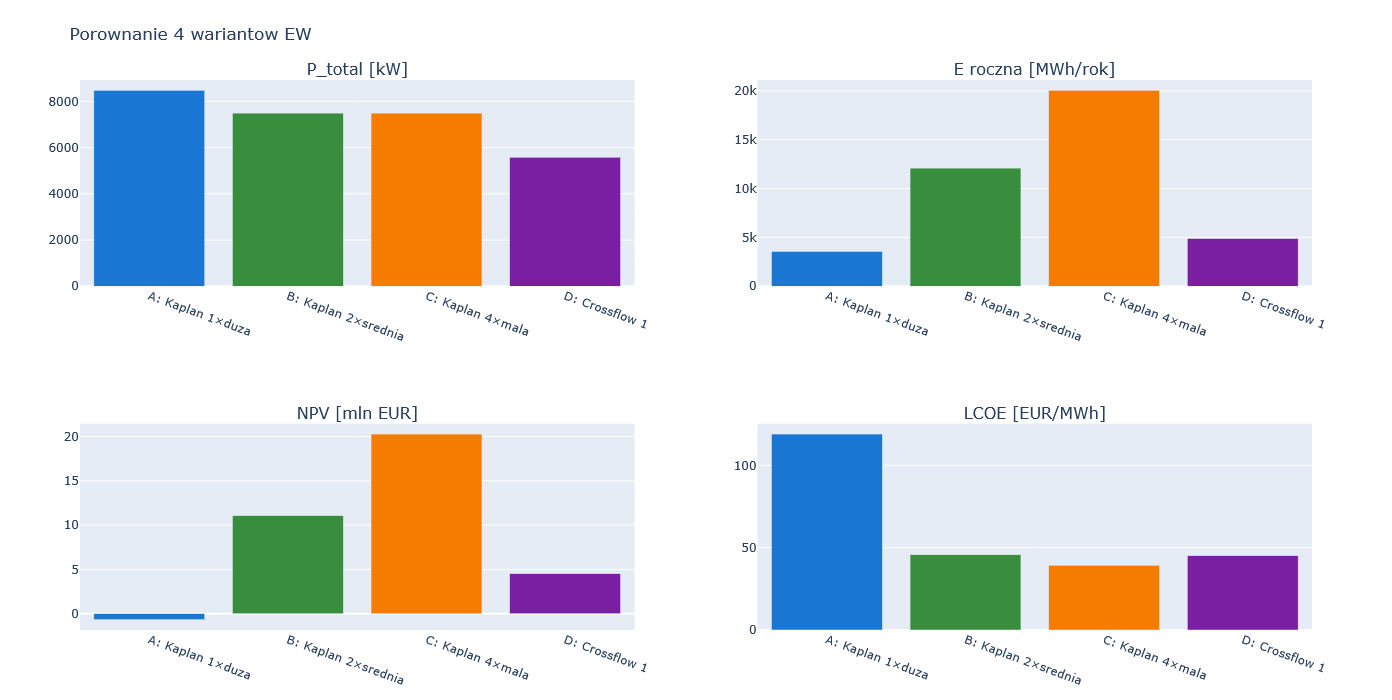

In [5]:
# 4-panel: P_total, E, NPV, LCOE
fig = make_subplots(rows=2, cols=2,
    subplot_titles=['P_total [kW]', 'E roczna [MWh/rok]',
                    'NPV [mln EUR]', 'LCOE [EUR/MWh]'])
colors = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']
for col_name, row, col in [('P_total [kW]', 1, 1), ('E [MWh/rok]', 1, 2),
                            ('NPV [mln EUR]', 2, 1), ('LCOE [EUR/MWh]', 2, 2)]:
    fig.add_trace(go.Bar(x=df_compare['Wariant'], y=df_compare[col_name],
        marker_color=colors[:len(df_compare)], showlegend=False), row=row, col=col)
fig.update_layout(height=700, title='Porownanie 4 wariantow EW',
    margin=dict(t=80, b=60))
fig.update_xaxes(tickangle=20)
fig.show()

## Krok 5: Naklozenie krzywych mocy

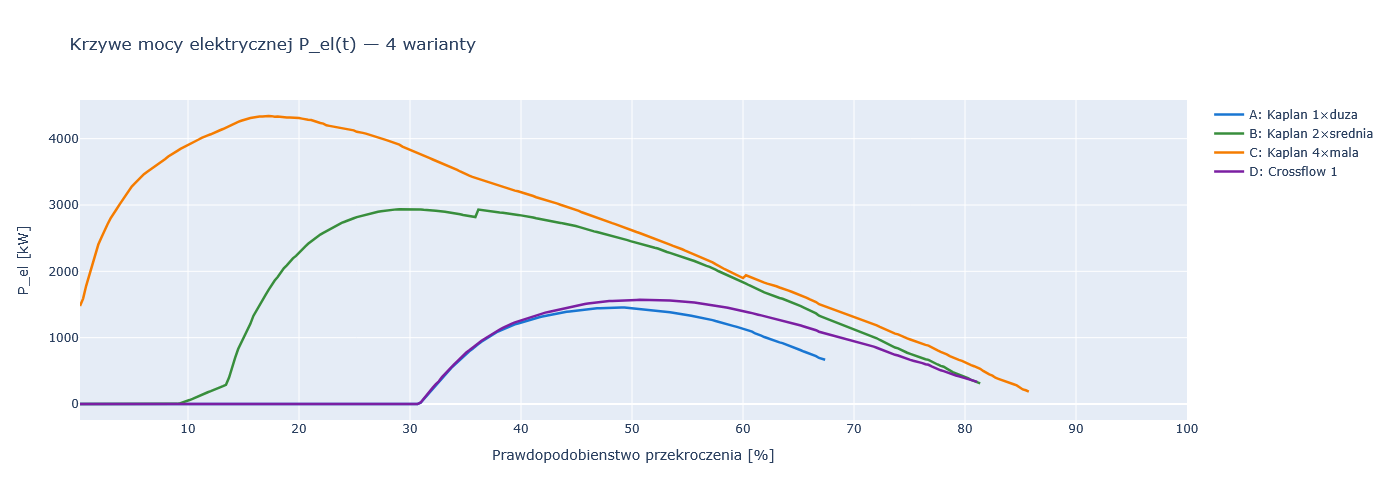

In [6]:
fig = go.Figure()
for label, color in zip(df_compare['Wariant'], colors):
    r = results_dfs[label]
    p = np.where(r['n_active'] > 0, r['P_el_kW'], np.nan)
    fig.add_trace(go.Scatter(x=r['pct'], y=p, mode='lines',
        name=label, line=dict(color=color, width=2.5), connectgaps=False))
fig.update_layout(
    title='Krzywe mocy elektrycznej P_el(t) — 4 warianty',
    xaxis_title='Prawdopodobienstwo przekroczenia [%]',
    yaxis_title='P_el [kW]',
    height=500, hovermode='x unified',
)
fig.show()

## Krok 6: Dyskusja

Każdy wariant wygrywa na innym kryterium. Wybór zależy od **priorytetów inwestora**:

| Priorytet inwestora | Wybor | Dlaczego |
|---------------------|-------|----------|
| Maksimum produkcji energii | Wariant o max E | Sumaryczna roczna energia |
| Maksimum zysku ekonomicznego | Wariant o max NPV | Całkowity zysk dyskontowany |
| Konkurencyjność z innymi źródłami | Wariant o min LCOE | Najniższy koszt produkcji jednej MWh |
| Szybki zwrot kapitału | Wariant o min payback | Konserwatywny inwestor |
| Elastyczność operacyjna | Więcej turbin (C) | Plant pracuje na szerszym zakresie Q |

**Brak "jednego najlepszego" wariantu** — to istotny wniosek. Decyzja zależy od
kontekstu (regulacje, finansowanie, ryzyko hydrologiczne, oczekiwania interesariuszy).

**Dalej:** nb 12 — pełna optymalizacja **algorytmem genetycznym** + **front Pareto**,
który pokazuje *wszystkie* niezdominowane warianty na osiach NPV vs LCOE.